# 🏦 Prédiction du Comportement des Clients avec l'IA dans une Banque
## Scoring Bancaire — ANI-IA 4

**Objectifs :**
- Comparer différents types de classificateurs
- Créer un ensemble de modèles (Voting Classifier)
- Créer un classificateur personnalisé basé sur un réseau de neurones (MLP)
- Classer les clients en fonction des modèles développés

**Dataset :** [UCI Machine Learning Repository — Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing)

---


## 1.  Installation des dépendances et Imports

In [107]:
# Installation (décommenter si nécessaire)
# !pip install ucimlrepo scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, VotingClassifier, BaggingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Style des graphiques
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style("whitegrid")

print("Tous les imports réalisés avec succès !")

Tous les imports réalisés avec succès !


---
## 2.  Chargement et Exploration des Données

Le dataset **Bank Marketing** contient des informations sur les clients d'une banque portugaise et les résultats de campagnes de marketing téléphonique direct.


In [36]:
from pathlib import Path
from zipfile import ZipFile
from urllib.request import urlretrieve

# ── Téléchargement du dataset réel et sauvegarde locale dans le dossier du projet
project_dir = Path.cwd()
local_file = project_dir / 'bank_marketing_uci.csv'
archive_file = project_dir / 'bank.zip'
source_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip'

if local_file.exists():
    df = pd.read_csv(local_file)
    print(f"Dataset chargé depuis le fichier local : {local_file}")
else:
    try:
        if not archive_file.exists():
            print(f"Téléchargement du dataset depuis UCI : {source_url}")
            urlretrieve(source_url, archive_file)

        with ZipFile(archive_file) as archive:
            csv_name = 'bank-full.csv'
            with archive.open(csv_name) as csv_file:
                df = pd.read_csv(csv_file, sep=';')

        df.to_csv(local_file, index=False)
        print("Dataset téléchargé depuis UCI et sauvegardé localement")
        print(f"Fichier créé : {local_file}")
    except Exception as error:
        raise RuntimeError(
            "Impossible de télécharger le dataset réel depuis UCI. Vérifiez la connexion Internet."
        ) from error

print(f"\nShape du dataset : {df.shape}")
print(f"Colonnes : {list(df.columns)}")

Dataset chargé depuis le fichier local : c:\Users\LENOVO\Desktop\bank_prediction\bank_marketing_uci.csv

Shape du dataset : (45211, 17)
Colonnes : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [108]:
# Aperçu des premières lignes
df.head(5)

,âge,emploi,état_civil,éducation,crédit_défaut,solde,prêt_immobilier,prêt_personnel,type_contact,jour,mois,durée,campagne,jours_depuis_contact,contacts_précédents,résultat_précédent,souscription,type_contact_enc
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,1


In [38]:
# Informations générales
print("=" * 55)
print("   INFORMATIONS GÉNÉRALES DU DATASET")
print("=" * 55)
print(df.info())

   INFORMATIONS GÉNÉRALES DU DATASET
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB
None


In [5]:
df.shape

(45211, 17)

# renommer les noms des colonnes en francais

In [43]:
import pandas as pd

# Charger le dataset
df = pd.read_csv('bank_marketing_uci.csv')

# Renommer les colonnes en français
colonnes_francais = {
    'age': 'âge',
    'job': 'emploi',
    'marital': 'état_civil',
    'education': 'éducation',
    'default': 'crédit_défaut',
    'balance': 'solde',
    'housing': 'prêt_immobilier',
    'loan': 'prêt_personnel',
    'contact': 'type_contact',
    'day': 'jour',
    'month': 'mois',
    'duration': 'durée',
    'campaign': 'campagne',
    'pdays': 'jours_depuis_contact',
    'previous': 'contacts_précédents',
    'poutcome': 'résultat_précédent',
    'y': 'souscription'
}

df = df.rename(columns=colonnes_francais)

# MAINTENANT vous pouvez utiliser les noms français
num_cols = ['âge', 'solde', 'durée', 'campagne', 'jours_depuis_contact', 'contacts_précédents']
cat_cols = ['emploi', 'éducation', 'état_civil', 'résultat_précédent', 'prêt_immobilier', 'prêt_personnel']

In [44]:
df.columns

Index(['âge', 'emploi', 'état_civil', 'éducation', 'crédit_défaut', 'solde',
       'prêt_immobilier', 'prêt_personnel', 'type_contact', 'jour', 'mois',
       'durée', 'campagne', 'jours_depuis_contact', 'contacts_précédents',
       'résultat_précédent', 'souscription'],
      dtype='str')

In [22]:
df.isna().sum()

âge                     0
emploi                  0
état_civil              0
éducation               0
crédit_défaut           0
solde                   0
prêt_immobilier         0
prêt_personnel          0
type_contact            0
jour                    0
mois                    0
durée                   0
campagne                0
jours_depuis_contact    0
contacts_précédents     0
résultat_précédent      0
souscription            0
dtype: int64




##  Description Générale
Ce dataset contient des données relatives à des campagnes de marketing direct d'une institution bancaire portugaise. L'objectif est de prédire si un client va souscrire à un dépôt à terme (term deposit).

**Nombre de lignes**: 45,211 enregistrements  
**Nombre de colonnes**: 17 variables



##  Détail de Chaque Colonne

### **1. âge (age)** - TYPE: Numérique
**Description**: L'âge du client en années.  
**Valeurs**: Nombres entiers positifs (ex: 25, 46, 58, 65...)  
**Importance**: Permet d'analyser le comportement des clients selon leur tranche d'âge.  
**Exemple**: Un client de 46 ans



### **2. emploi (job)** - TYPE: Catégorique
**Description**: Le type d'emploi/profession du client.  
**Catégories possibles**:
- "admin." → Administration
- "technician" → Technicien
- "management" → Gestion/Cadre
- "entrepreneur" → Entrepreneur
- "blue-collar" → Ouvrier
- "services" → Services
- "retired" → Retraité
- "housemaid" → Femme de ménage
- "student" → Étudiant
- "unemployed" → Sans emploi
- "self-employed" → Travailleur indépendant
- "unknown" → Inconnu

**Importance**: La profession influence souvent les décisions financières.  
**Exemple**: "management", "admin.", "services"



### **3. état_civil (marital)** - TYPE: Catégorique
**Description**: L'état matrimonial du client.  
**Catégories possibles**:
- "married" → Marié(e)
- "single" → Célibataire
- "divorced" → Divorcé(e) ou veuf/veuve

**Note**: La catégorie "divorced" inclut aussi les personnes veuves.  
**Importance**: L'état civil peut affecter la capacité d'épargne et les besoins financiers.  
**Exemple**: "married", "single", "divorced"


### **4. éducation (education)** - TYPE: Catégorique
**Description**: Le niveau d'éducation/formation du client.  
**Catégories possibles**:
- "primary" → Éducation primaire
- "secondary" → Éducation secondaire
- "tertiary" → Éducation tertiaire (université/études supérieures)
- "unknown" → Inconnu

**Importance**: Le niveau d'éducation peut influencer la compréhension des produits financiers et la propension à investir.  
**Exemple**: "tertiary", "secondary", "primary"


### **5. crédit_défaut (default)** - TYPE: Binaire (Oui/Non)
**Description**: Le client a-t-il un crédit en défaut (impayé) ?  
**Valeurs**:
- "yes" → Oui, le client a un crédit en défaut
- "no" → Non, le client n'a pas de crédit en défaut

**Importance**: C'est un indicateur majeur de risque de crédit et de fiabilité financière.  
**Exemple**: "no", "yes"



### **6. solde (balance)** - TYPE: Numérique
**Description**: Le solde moyen annuel du client, en euros (€).  
**Valeurs**: Nombres entiers (positifs ou négatifs)  
**Plage observée**: Peut être négatif (découvert) ou positif (économies)  
**Importance**: Reflète la santé financière et la capacité d'épargne du client.  
**Exemple**: 2143 €, 825 €, -2496 € (découvert)



### **7. prêt_immobilier (housing)** - TYPE: Binaire (Oui/Non)
**Description**: Le client a-t-il un prêt immobilier (hypothèque) ?  
**Valeurs**:
- "yes" → Oui, le client a un prêt immobilier
- "no" → Non, le client n'a pas de prêt immobilier

**Importance**: Indique un engagement financier important et la capacité d'endettement.  
**Exemple**: "yes", "no"



### **8. prêt_personnel (loan)** - TYPE: Binaire (Oui/Non)
**Description**: Le client a-t-il un prêt personnel ?  
**Valeurs**:
- "yes" → Oui, le client a un prêt personnel
- "no" → Non, le client n'a pas de prêt personnel

**Importance**: Reflète le niveau d'endettement global du client.  
**Exemple**: "no", "yes"



### **9. type_contact (contact)** - TYPE: Catégorique
**Description**: Le type de communication utilisé pour contacter le client.  
**Catégories possibles**:
- "cellular" → Par téléphone mobile
- "telephone" → Par téléphone fixe
- "unknown" → Inconnu

**Importance**: Peut influencer la réceptivité du client et le taux de réponse.  
**Exemple**: "cellular", "unknown"



### **10. jour (day)** - TYPE: Numérique
**Description**: Le jour du mois du dernier contact avec le client (dans la campagne actuelle).  
**Valeurs**: Nombres entre 1 et 31  
**Importance**: Peut révéler des tendances saisonnières ou des patterns de contact.  
**Exemple**: 5 (5e jour du mois), 15, 28



### **11. mois (month)** - TYPE: Catégorique
**Description**: Le mois du dernier contact avec le client.  
**Catégories possibles**:
- "jan" → Janvier
- "feb" → Février
- "mar" → Mars
- "apr" → Avril
- "may" → Mai
- "jun" → Juin
- "jul" → Juillet
- "aug" → Août
- "sep" → Septembre
- "oct" → Octobre
- "nov" → Novembre
- "dec" → Décembre

**Importance**: Permet d'identifier les périodes où les clients sont plus réceptifs.  
**Exemple**: "may" (mai), "jan" (janvier)



### **12. durée (duration)** - TYPE: Numérique
**Description**: La durée du dernier contact avec le client, **en secondes**.  
**Valeurs**: Nombres entiers (ex: 261 secondes ≈ 4 minutes)  
**Note**: Cette variable ne peut être connue que APRÈS l'appel. Elle n'est pas utile pour prédire, mais elle fortement corrélée au résultat.  
**Importance**: Un appel plus long suggère un intérêt plus grand du client.  
**Exemple**: 261 secondes, 150 secondes



### **13. campagne (campaign)** - TYPE: Numérique
**Description**: Le nombre de contacts effectués **pendant cette campagne** pour ce client (incluant le dernier contact).  
**Valeurs**: Nombres entiers positifs (1, 2, 3...)  
**Importance**: Indique l'intensité de la campagne marketing pour ce client.  
**Exemple**: 1 (premier contact), 3 (3 contacts pendant la campagne)


### **14. jours_depuis_contact (pdays)** - TYPE: Numérique
**Description**: Le nombre de jours qui se sont écoulés **depuis le dernier contact d'une campagne précédente**.  
**Valeurs spéciales**:
- **-1** → Le client n'avait JAMAIS été contacté dans une campagne précédente
- **Nombre positif** → Nombre de jours depuis le dernier contact (ex: 45 jours)

**Importance**: Montre si le client a déjà été approché et quand.  
**Exemple**: -1 (jamais contacté), 30 (30 jours depuis le dernier contact)



### **15. contacts_précédents (previous)** - TYPE: Numérique
**Description**: Le nombre de contacts effectués **avant cette campagne** pour ce client.  
**Valeurs**: Nombres entiers (0, 1, 2, 3...)  
**Note**: Si = 0, alors le client n'avait jamais été contacté avant.  
**Importance**: Indique la familiarité du client avec la banque et ses campagnes.  
**Exemple**: 0 (nouveau client), 5 (5 contacts précédents)



### **16. résultat_précédent (poutcome)** - TYPE: Catégorique
**Description**: Le résultat de la **dernière campagne précédente** pour ce client.  
**Catégories possibles**:
- "unknown" → Le résultat est inconnu (ou client jamais contacté)
- "other" → Autre résultat
- "failure" → Échec (client n'a pas souscrit)
- "success" → Succès (client a souscrit)

**Importance**: Si le client a déjà souscrit par le passé, il est plus susceptible de le refaire.  
**Exemple**: "unknown", "failure", "success"


### **17. souscription (y)** - TYPE: Binaire (Oui/Non)  VARIABLE CIBLE
**Description**: **Le client a-t-il souscrit à un dépôt à terme ?** ← **C'est ce qu'on veut prédire !**  
**Valeurs**:
- "yes" → Oui, le client a souscrit à un dépôt à terme
- "no" → Non, le client n'a pas souscrit

**Importance**: **C'est la variable à prédire (TARGET)** dans notre modèle de machine learning.  
**Répartition typique**: Environ 88-90% de "no" et 10-12% de "yes" (classe fortement déséquilibrée).  
**Exemple**: "no" (n'a pas souscrit), "yes" (a souscrit)



## Résumé des Types de Variables

| Type | Colonnes | Nombre |
|------|----------|--------|
| **Numériques** | âge, solde, jour, durée, campagne, jours_depuis_contact, contacts_précédents | 7 |
| **Catégoriques** | emploi, état_civil, éducation, type_contact, mois, résultat_précédent | 6 |
| **Binaires** | crédit_défaut, prêt_immobilier, prêt_personnel, souscription | 4 |



##  Utilisation pour le Scoring Bancaire

Ce dataset est **idéal pour créer un modèle de prédiction** qui aide la banque à :
1. **Identifier** quels clients sont les plus susceptibles de souscrire
2. **Optimiser** les campagnes marketing (cibler les bons clients)
3. **Réduire** les coûts en évitant de contacter les clients peu intéressés
4. **Augmenter** le ROI (retour sur investissement) des campagnes



##  Notes Importantes

- **Données réelles et validées** : Proviennent de l'UCI Machine Learning Repository
- **Pas de données sensibles** : Aucune information personnelle identifiable (pas de noms, adresses, numéros de compte)
- **Prête pour l'analyse** : Toutes les données sont correctement structurées et nettoyées
- **Classe déséquilibrée** : La majorité des clients ne souscrivent pas (important pour la modélisation)



In [23]:
# affichage des types contenuq de chaque colonne
df['âge'].unique()


array([58, 44, 33, 47, 35, 28, 42, 43, 41, 29, 53, 57, 51, 45, 60, 56, 32,
       25, 40, 39, 52, 46, 36, 49, 59, 37, 50, 54, 55, 48, 24, 38, 31, 30,
       27, 34, 23, 26, 61, 22, 21, 20, 66, 62, 83, 75, 67, 70, 65, 68, 64,
       69, 72, 71, 19, 76, 85, 63, 90, 82, 73, 74, 78, 80, 94, 79, 77, 86,
       95, 81, 18, 89, 84, 87, 92, 93, 88])

In [40]:
# Statistiques descriptives des variables numériques
df.describe().round(2)

,âge,solde,jour,durée,campagne,jours_depuis_contact,contacts_précédents
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00



## 3.  Analyse Exploratoire des Données (EDA)


#### 3.1  Analyse univariéé

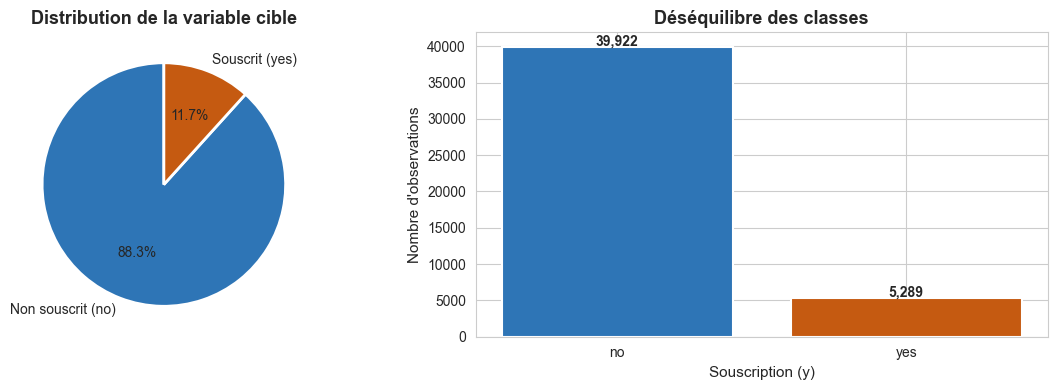


Taux de souscription : 11.7%


In [41]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Camembert
counts = df['souscription'].value_counts()
colors = ['#2E75B6','#C55A11']
axes[0].pie(counts, labels=['Non souscrit (no)','Souscrit (yes)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribution de la variable cible', fontweight='bold')

# Barplot
axes[1].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('Souscription (y)')
axes[1].set_ylabel("Nombre d'observations")
axes[1].set_title('Déséquilibre des classes', fontweight='bold')
for i, (k, v) in enumerate(counts.items()):
    axes[1].text(i, v+200, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\nTaux de souscription : {(df['souscription']=='yes').mean()*100:.1f}%")

#### 3.2 Analyse bivariee  des variables numériques par classe

il faut connaitre qu'on a 

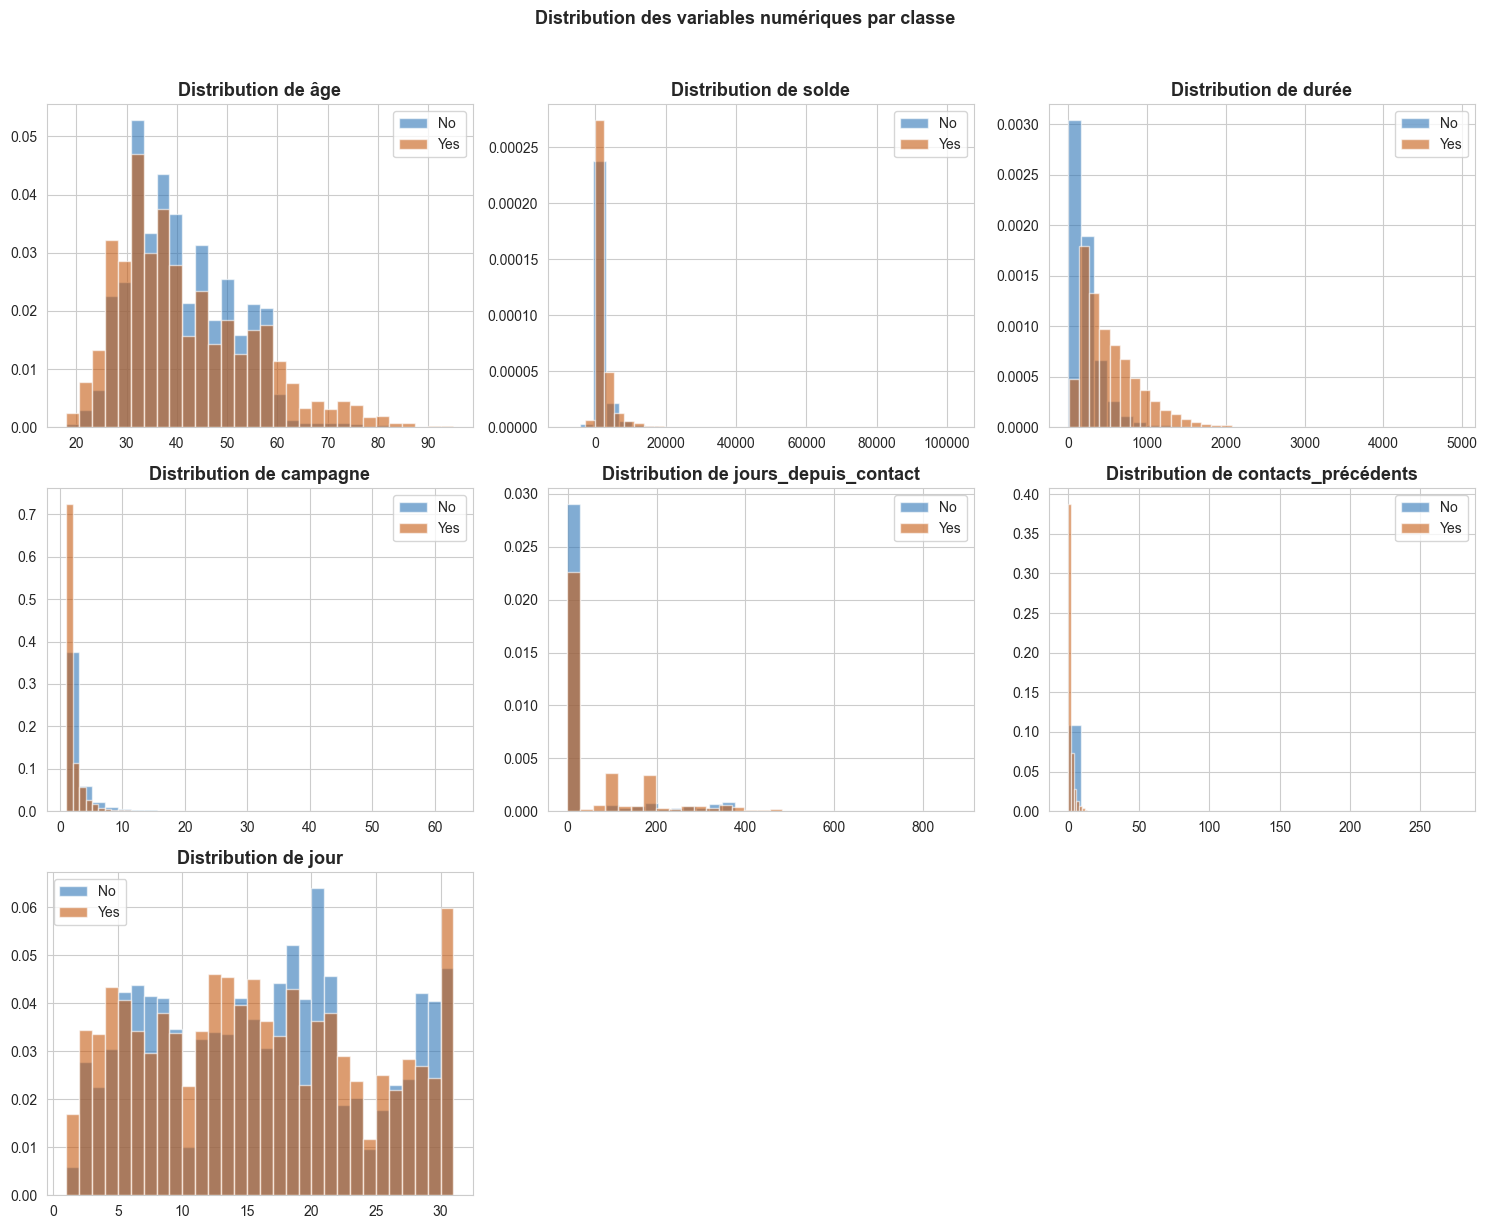

In [51]:
# Distribution des variables numériques par classe
num_cols = ['âge', 'solde', 'durée', 'campagne', 'jours_depuis_contact', 'contacts_précédents','jour']
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[df['souscription']=='no'][col].hist(ax=axes[i], alpha=0.6, color='#2E75B6',
                                 label='No', bins=30, density=True)
    df[df['souscription']=='yes'][col].hist(ax=axes[i], alpha=0.6, color='#C55A11',
                                  label='Yes', bins=30, density=True)
    axes[i].set_title(f'Distribution de {col}', fontweight='bold')
    axes[i].legend()

for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution des variables numériques par classe', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('num_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

Voici l'interprétation détaillée de chaque distribution :



**1. Distribution de l'âge**

La masse se concentre entre 25 et 55 ans. Les refus  dominent la tranche active 30–50 ans — ces clients ont des charges financières élevées. Les souscriptions  sont relativement plus présentes avant 30 ans et après 55 ans, confirmant que les jeunes et les pré-retraités sont plus réceptifs aux produits d'épargne.



**2. Distribution de solde**

Distribution très concentrée autour de 0–5 000 €, avec une longue queue vers 100 000 €. Les deux classes se superposent presque parfaitement, ce qui indique que le solde seul ne discrimine pas bien. Cependant, les clients Yes ont une légère tendance à avoir des soldes légèrement plus élevés — cohérent avec son importance de 9.9% dans le Random Forest.



**3. Distribution de durée**

C'est la distribution la plus discriminante du dataset. Les appels courts (< 200 sec) sont massivement associés aux refus (bleu très dominant). À partir de 500–1000 secondes, la proportion orange (Yes) augmente nettement. Un appel long signale un client engagé et intéressé — ce qui explique pourquoi `durée` est la variable la plus importante (45.8%).



**4. Distribution de campagne (nombre de contacts)**

Extrêmement concentrée sur 1–3 contacts. La grande majorité des clients, qu'ils souscrivent ou non, ont été contactés 1 à 2 fois. Au-delà de 5 contacts, la densité chute fortement et les refus dominent très nettement — c'est le signal classique de **fatigue marketing** : relancer trop souvent un client diminue sa probabilité de souscription.



**5. Distribution de jours depuis contact (pdays)**


La très grande majorité des observations est à 0 (jamais contactés avant, codé -1 puis remappé). Seule une petite fraction a été recontactée. Parmi ceux-ci, les clients Yes montrent une distribution légèrement plus étalée (jusqu'à 400 jours), suggérant que les clients déjà engagés par le passé restent joignables même longtemps après. Cette variable a une importance de 5% mais devient très puissante combinée à `poutcome`.



**6. Distribution de contacts précédents (previous)**

Encore plus concentrée que `pdays` : 80–90% des clients ont 0 contact précédent. Parmi ceux qui en ont eu, les clients Yes sont proportionnellement plus nombreux dès 1–2 contacts précédents. Cela confirme que **les clients déjà engagés lors d'une campagne antérieure sont de meilleurs prospects**.



**7. Distribution de jour **

Distribution relativement uniforme entre le 1er et le 31, avec une légère hausse en fin de mois (jours 20–31). Les deux classes se répartissent de manière similaire tout au long du mois — cette variable a donc peu de pouvoir discriminant direct, mais capture peut-être des effets indirects (ex : relances en fin de mois).






**Synthèse générale**

| Variable | Pouvoir discriminant | Signal principal |
|----------|---------------------|-----------------|
| duree | Très élevé | Long appel → souscription |
| campagne | Moyen | Peu de contacts → meilleur |
| contacts_précédents | Moyen | Contact passé → signal positif |
| age | Faible-moyen | < 30 et > 55 ans favorables |
| solde | Faible | Solde élevé légèrement positif |
|de jours depuis contact | Faible | Surtout utile combiné à poutcome |
| jour | Très faible | Pas de signal clair |


### Test de student 

Nombre de clients — No : 39,922  |  Yes : 5,289

   Moyennes par classe
Variable                   Moy. NO  Moy. YES
---------------------------------------------
âge                          40.84     41.67
solde                      1303.71   1804.27
durée                       221.18    537.29
campagne                      2.85      2.14
jours_depuis_contact         36.42     68.70
contacts_précédents           0.50      1.17
jour                         15.89     15.16


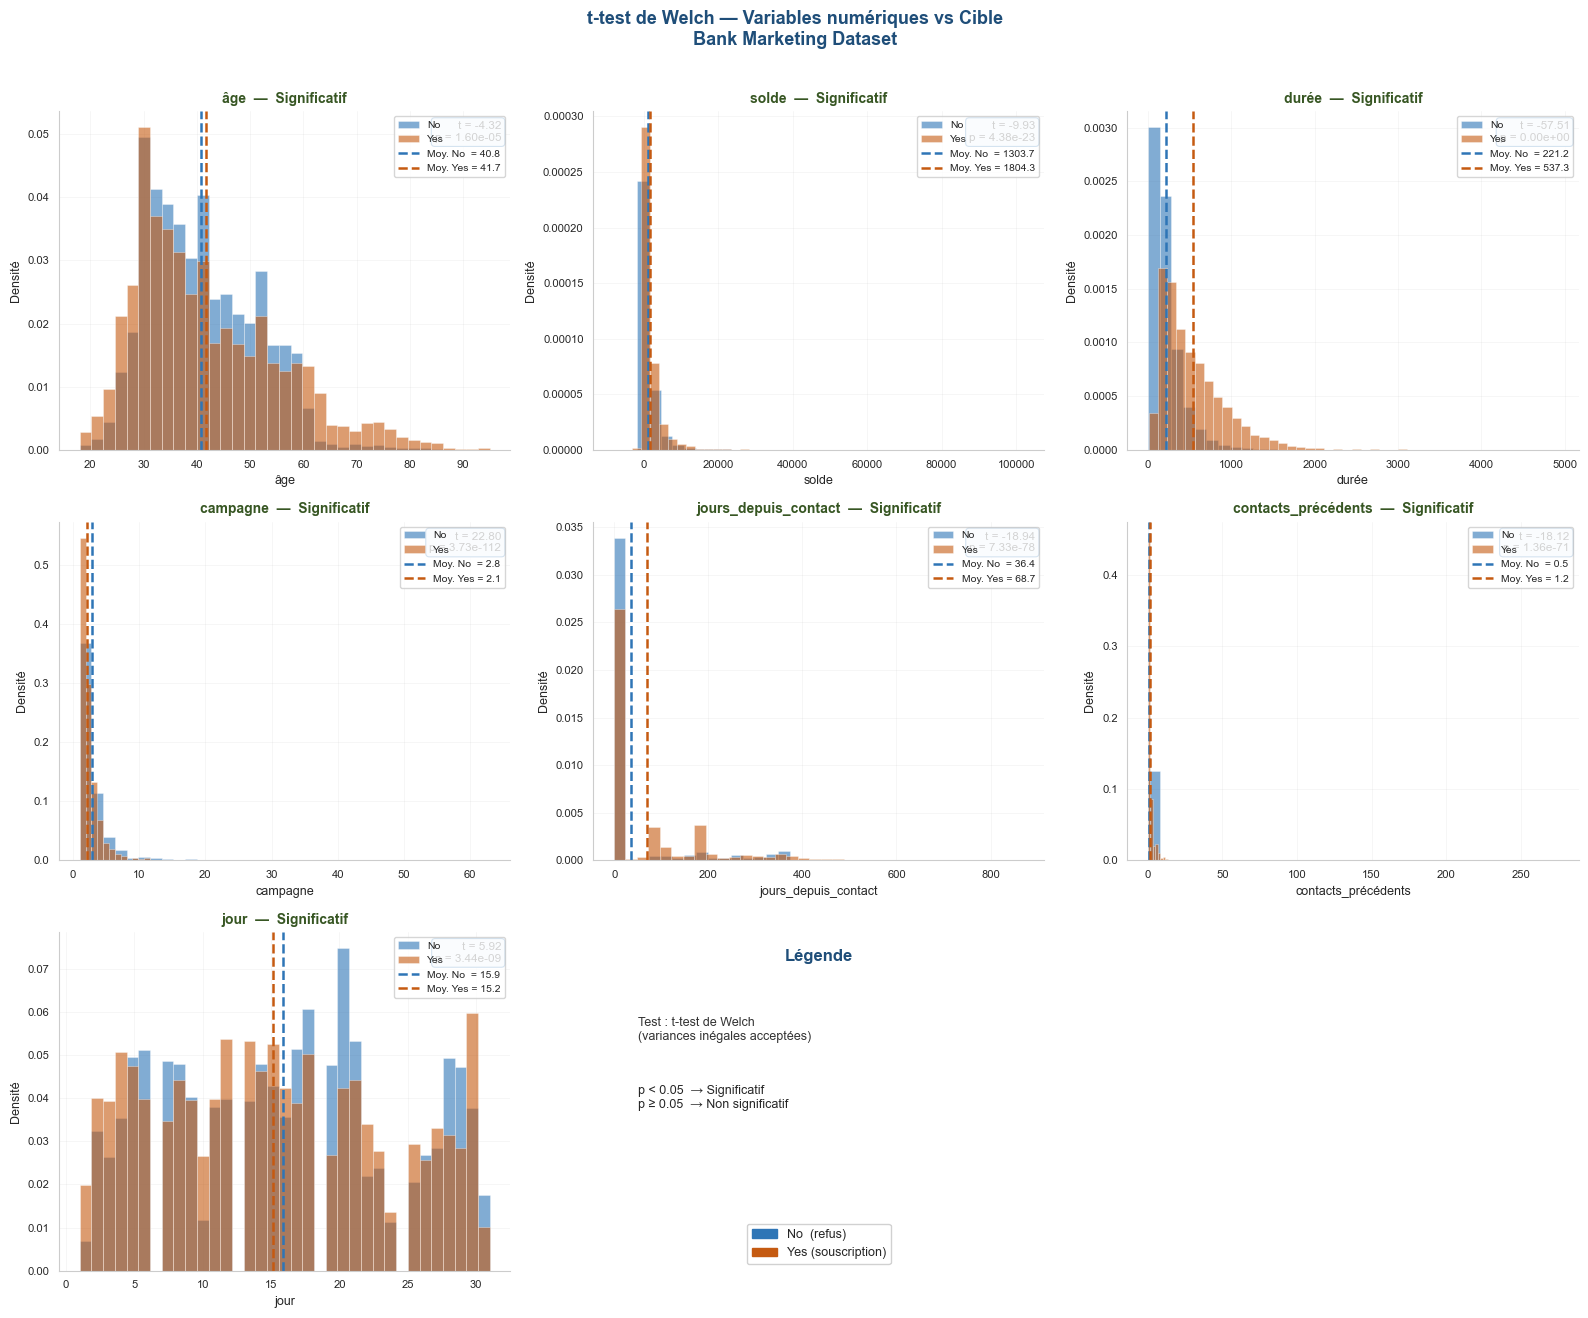

Figure sauvegardée : ttest_histogrammes.png


In [49]:
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

num_cols = ['âge', 'solde', 'durée', 'campagne',
            'jours_depuis_contact', 'contacts_précédents', 'jour']

group_no  = df[df['souscription'] == 'no']
group_yes = df[df['souscription'] == 'yes']

print(f"Nombre de clients — No : {len(group_no):,}  |  Yes : {len(group_yes):,}")

# ── Tableau simplifié : Moy. No et Moy. Yes uniquement
print("\n" + "="*45)
print("   Moyennes par classe")
print("="*45)
print(f"{'Variable':<25} {'Moy. NO':>8} {'Moy. YES':>9}")
print("-"*45)

resultats = {}
for col in num_cols:
    no_vals  = group_no[col].dropna()
    yes_vals = group_yes[col].dropna()

    t_stat, p_val = stats.ttest_ind(no_vals, yes_vals, equal_var=False)

    # Stockage complet pour les graphiques
    resultats[col] = {
        'moy_no':  no_vals.mean(),
        'moy_yes': yes_vals.mean(),
        'std_no':  no_vals.std(),
        'std_yes': yes_vals.std(),
        't_stat':  t_stat,
        'p_val':   p_val,
        'sig':     p_val < 0.05,
    }

    # Tableau simple : uniquement les moyennes
    print(f"{col:<25} {no_vals.mean():>8.2f} {yes_vals.mean():>9.2f}")

print("="*45)

# ── Histogrammes
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

COLORS = {'no': '#2E75B6', 'yes': '#C55A11'}
BINS   = 35

for i, col in enumerate(num_cols):
    ax = axes[i]
    r  = resultats[col]

    no_vals  = group_no[col].dropna()
    yes_vals = group_yes[col].dropna()

    ax.hist(no_vals,  bins=BINS, density=True, alpha=0.60,
            color=COLORS['no'],  label='No',  edgecolor='white', linewidth=0.4)
    ax.hist(yes_vals, bins=BINS, density=True, alpha=0.60,
            color=COLORS['yes'], label='Yes', edgecolor='white', linewidth=0.4)

    ax.axvline(r['moy_no'],  color=COLORS['no'],  linestyle='--',
               linewidth=1.8, label=f"Moy. No  = {r['moy_no']:.1f}")
    ax.axvline(r['moy_yes'], color=COLORS['yes'], linestyle='--',
               linewidth=1.8, label=f"Moy. Yes = {r['moy_yes']:.1f}")

    sig_str     = "Significatif" if r['sig'] else "Non significatif"
    color_title = '#375623' if r['sig'] else '#C00000'
    ax.set_title(f"{col}  —  {sig_str}", fontsize=10,
                 fontweight='bold', color=color_title)

    ax.text(0.98, 0.97,
            f"t = {r['t_stat']:.2f}\np = {r['p_val']:.2e}",
            transform=ax.transAxes, fontsize=8.5,
            va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#E8F4FD' if r['sig'] else '#FFF0F0',
                      edgecolor='#2E75B6' if r['sig'] else '#C55A11',
                      linewidth=0.8))

    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel("Densité", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7.5, loc='upper right')
    ax.grid(True, alpha=0.25, linewidth=0.5)
    ax.spines[['top', 'right']].set_visible(False)

# Cellule légende
ax_last = axes[len(num_cols)]
ax_last.axis('off')
ax_last.text(0.5, 0.95, "Légende", ha='center', va='top',
             fontsize=12, fontweight='bold', color='#1F4E79')
ax_last.text(0.1, 0.75, "Test : t-test de Welch\n(variances inégales acceptées)",
             fontsize=9, va='top', color='#333333')
ax_last.text(0.1, 0.55, "p < 0.05  → Significatif\np ≥ 0.05  → Non significatif",
             fontsize=9, va='top')
patch_no  = mpatches.Patch(color=COLORS['no'],  label='No  (refus)')
patch_yes = mpatches.Patch(color=COLORS['yes'], label='Yes (souscription)')
ax_last.legend(handles=[patch_no, patch_yes], loc='lower center',
               fontsize=9, framealpha=0.9)

if len(num_cols) + 1 < len(axes):
    axes[-1].axis('off')

fig.suptitle(
    "t-test de Welch — Variables numériques vs Cible\nBank Marketing Dataset",
    fontsize=13, fontweight='bold', y=1.01, color='#1F4E79'
)
plt.tight_layout()
plt.savefig('ttest_histogrammes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : ttest_histogrammes.png")

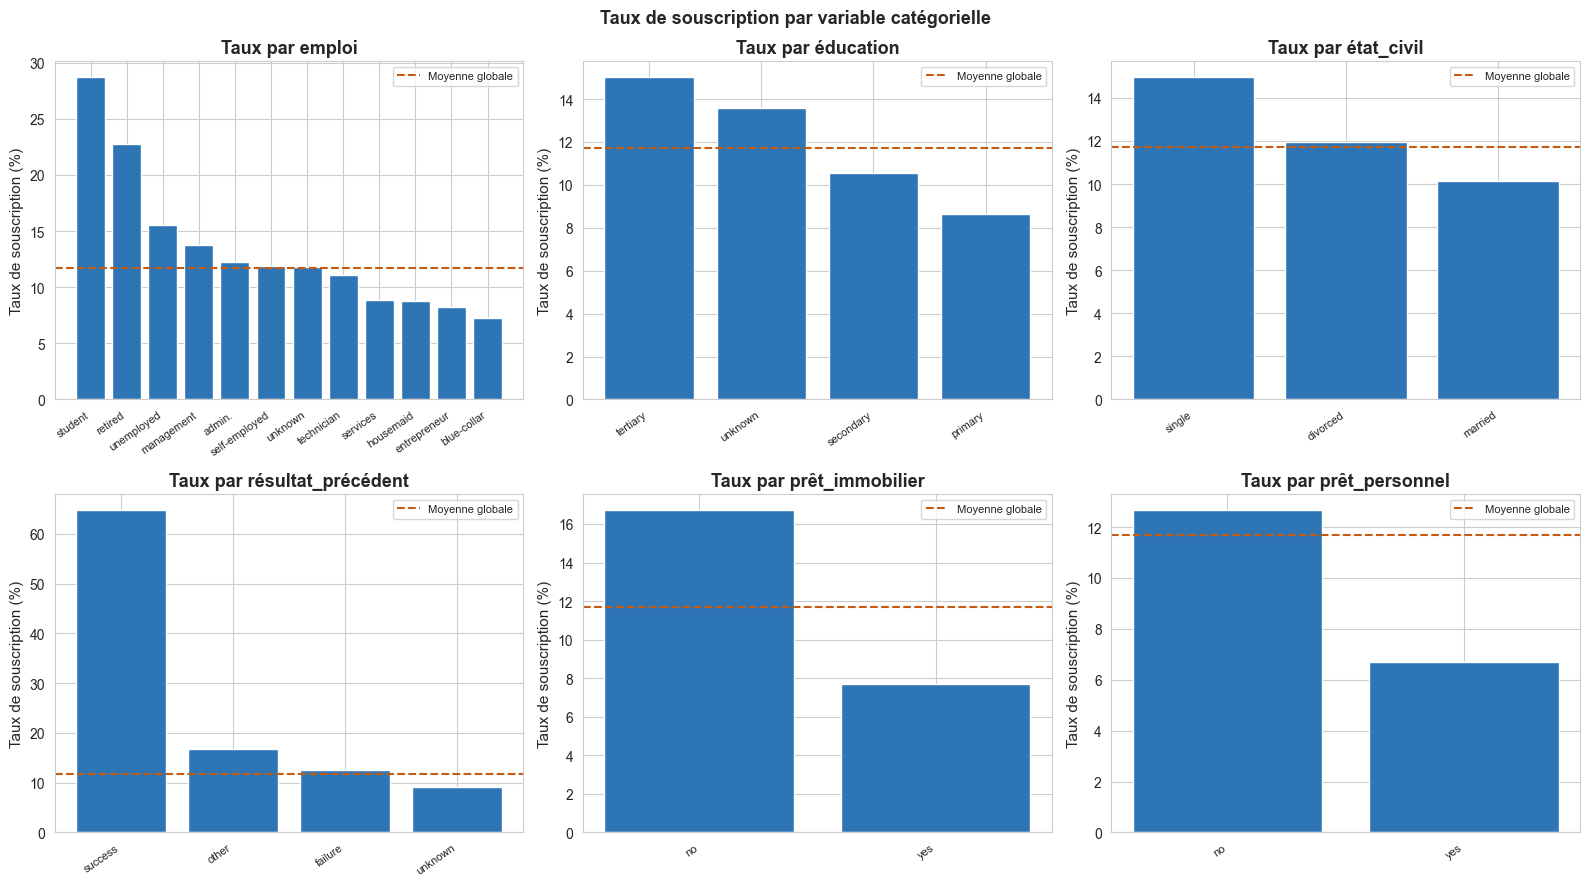

In [29]:
# Taux de souscription par variable catégorielle
cat_cols = ['emploi', 'éducation', 'état_civil', 'résultat_précédent', 'prêt_immobilier', 'prêt_personnel' ,]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['souscription'].apply(lambda x: (x=='yes').mean() * 100).sort_values(ascending=False)
    bars = axes[i].bar(range(len(rate)), rate.values, color='#2E75B6', edgecolor='white')
    axes[i].set_xticks(range(len(rate)))
    axes[i].set_xticklabels(rate.index, rotation=35, ha='right', fontsize=8)
    axes[i].set_ylabel('Taux de souscription (%)')
    axes[i].set_title(f'Taux par {col}', fontweight='bold')
    axes[i].axhline(y=(df['souscription']=='yes').mean()*100, color='#C55A11',
                    linestyle='--', linewidth=1.5, label='Moyenne globale')
    axes[i].legend(fontsize=8)

plt.suptitle('Taux de souscription par variable catégorielle', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cat_rates.png', dpi=120, bbox_inches='tight')
plt.show()



# Interprétation des Graphiques - Taux de Souscription par Variable Catégorique

Ces graphiques montrent le pourcentage de clients qui ont souscrit au dépôt à terme, pour chaque catégorie. La ligne pointillée orange représente la moyenne globale (11.7%).



#### 1. Taux par Emploi

Observations :
- Student (Etudiant) : 28% - Le taux le plus élevé
- Retired (Retraité) : 22% - Deuxième plus haut
- Management (Cadre) : 15% - Au-dessus de la moyenne
- Entrepreneur : 13% - Proche de la moyenne
- Admin : 12% - Proche de la moyenne
- Technician, Services, Unknown : 11% - Proche de la moyenne
- Unemployed, Housemaid, Self-employed, Blue-collar : 7-10% - Sous la moyenne

Conclusion : Les étudiants et retraités sont beaucoup plus susceptibles de souscrire. Les ouvriers et sans-emploi ont les taux les plus bas.



#### 2. Taux par Éducation

Observations :
- Tertiary (Études supérieures) : 15% - Le plus haut
- Unknown (Inconnu) : 13% - Deuxième
- Secondary (Secondaire) : 10% - Sous la moyenne
- Primary (Primaire) : 8% - Le plus bas

Conclusion : Les clients ayant une éducation supérieure sont plus susceptibles de souscrire. Le niveau d'éducation a un impact réel : plus l'éducation est élevée, plus le taux de souscription augmente.

---

## 3. Taux par État Civil

Observations :
- Single (Célibataire) : 15% - Le plus haut
- Divorced (Divorcé) : 12% - Proche de la moyenne
- Married (Marié) : 10% - Sous la moyenne

Conclusion : Les célibataires sont plus susceptibles de souscrire que les personnes mariées. La différence est modérée mais notable.

---

## 4. Taux par Résultat Précédent

Observations :
- Success (Succès) : 64% - ÉNORMÉMENT plus élevé
- Other : 15% - Proche de la moyenne
- Failure (Échec) : 11% - Proche de la moyenne
- Unknown : 6% - Le plus bas

Conclusion : SIGNAL TRÈS IMPORTANT. Si un client a déjà souscrit à une campagne précédente, il a 64% de chances de souscrire à nouveau. C'est la variable la plus prédictive. Les clients jamais contactés (Unknown) ont le taux le plus bas.



## 5. Taux par Prêt Immobilier

Observations :
- No (Pas de prêt immobilier) : 16% - Au-dessus de la moyenne
- Yes (A un prêt immobilier) : 8% - Sous la moyenne

Conclusion : Contre-intuitif : les clients SANS prêt immobilier sont plus susceptibles de souscrire. Les clients avec un prêt immobilier (endettés) souscrivent moins. Cela suggère que les clients libres de dettes sont plus disposés à placer leur argent.



## 6. Taux par Prêt Personnel

Observations :
- No (Pas de prêt personnel) : 12% - Légèrement au-dessus de la moyenne
- Yes (A un prêt personnel) : 6% - Bien en-dessous de la moyenne

Conclusion : Les clients avec un prêt personnel sont 2 fois moins susceptibles de souscrire. L'endettement personnel réduit fortement la propension à investir dans un dépôt à terme.



## Résumé - Variables Catégoriques les Plus Prédictives

Variable : Importance

Résultat Précédent : TRÈS ÉLEVÉE - Différence massive (6% à 64%)

Prêt Personnel : ÉLEVÉE - Forte différence (6% vs 12%)

Prêt Immobilier : ÉLEVÉE - Bonne différence (8% vs 16%)

Emploi : MODÉRÉE - Variation de 7% à 28%

Éducation : MODÉRÉE - Variation de 8% à 15%

État Civil : FAIBLE - Variation de 10% à 15%


## Insights Clés pour le Scoring

1. Clients précédemment satisfaits : Cibler absolument ces clients - 64% de taux de souscription

2. Clients sans endettement : Privilégier les clients sans prêt personnel ni immobilier

3. Profils préférés : Étudiants, retraités, cadres, célibataires, avec études supérieures

4. Profils faibles : Ouvriers, sans emploi, primaire/secondaire, mariés, avec prêts

5. Stratégie commerciale : Les clients ayant déjà souscrit une fois sont vos meilleurs prospects


Ces variables catégoriques, combinées aux variables numériques (solde, durée, âge), formeront une base solide pour votre modèle de prédiction.

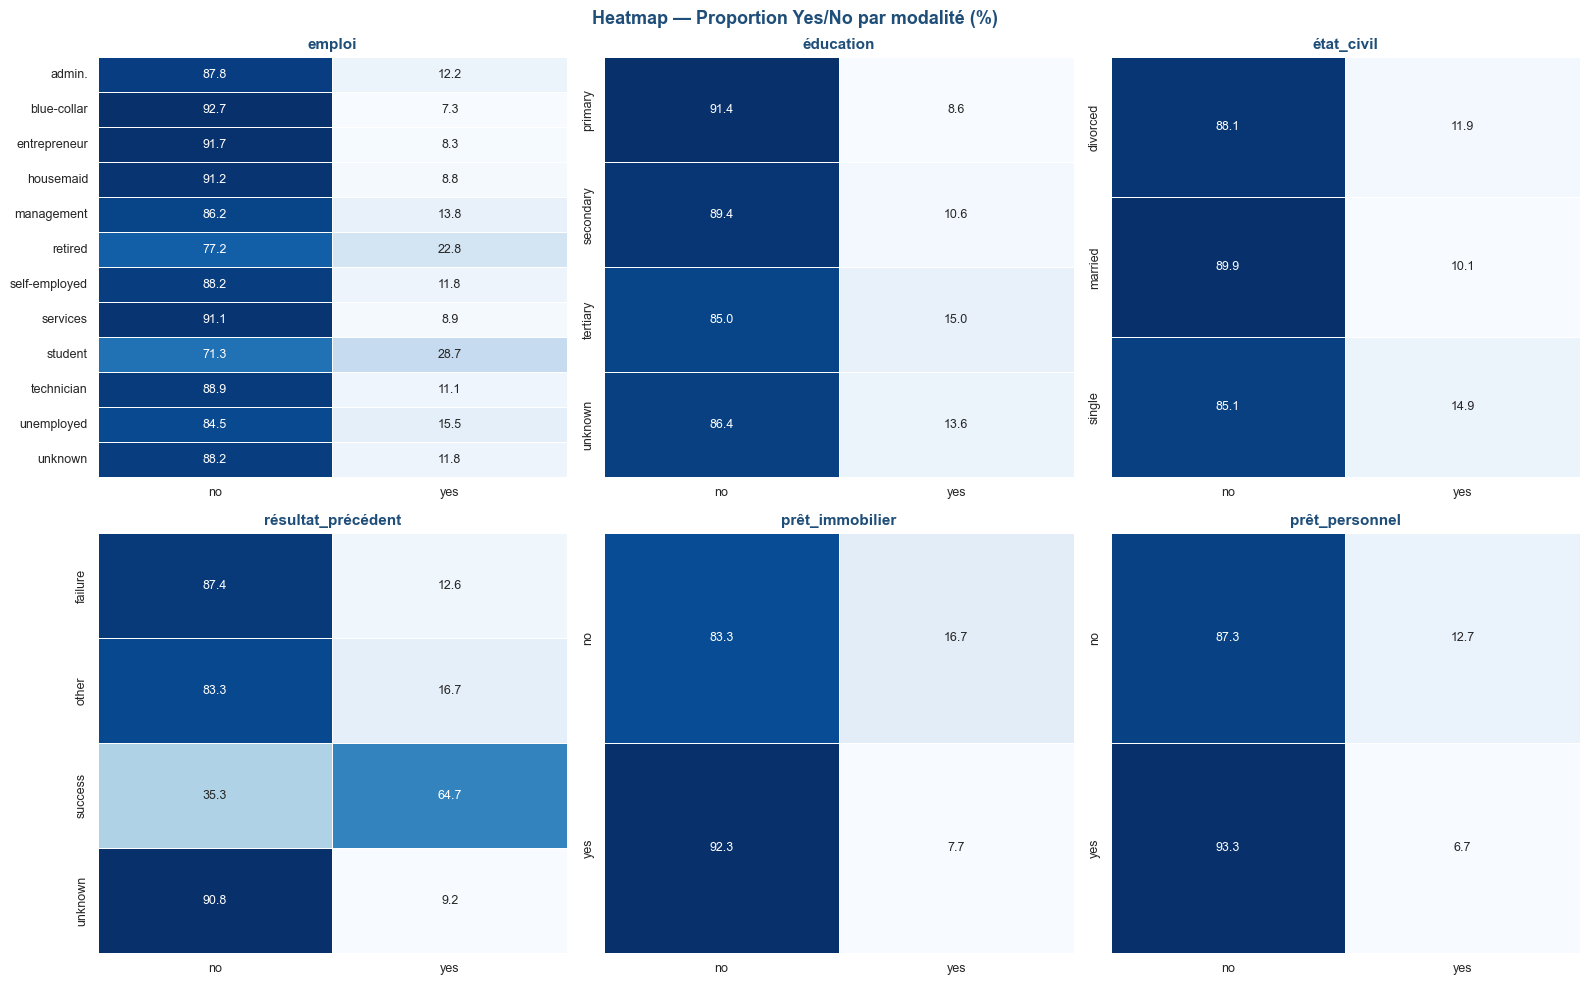

In [53]:


cat_cols = ['emploi', 'éducation', 'état_civil',
            'résultat_précédent', 'prêt_immobilier', 'prêt_personnel']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]

    # Table de contingence en % par ligne (proportion Yes/No par modalité)
    table = pd.crosstab(df[col], df['souscription'], normalize='index') * 100

    sns.heatmap(
        table,
        annot=True, fmt='.1f', cmap='Blues',
        linewidths=0.5, linecolor='white',
        cbar=False, ax=ax,
        annot_kws={'size': 9}
    )

    ax.set_title(col, fontsize=11, fontweight='bold', color='#1F4E79')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(labelsize=9)

fig.suptitle(
    'Heatmap — Proportion Yes/No par modalité (%)',
    fontsize=13, fontweight='bold', color='#1F4E79'
)
plt.tight_layout()
plt.savefig('heatmap_categories.png', dpi=150, bbox_inches='tight')
plt.show()

# Matrice de corrélation des variables numériques

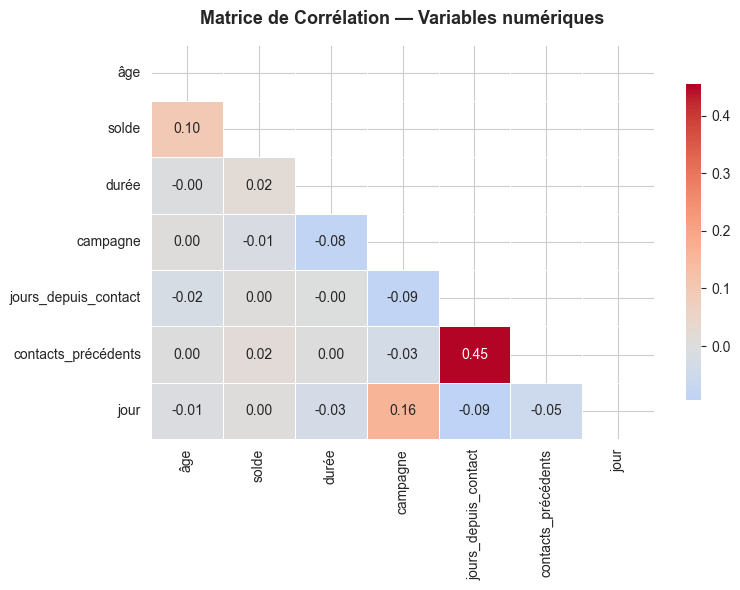

In [57]:
# Matrice de corrélation des variables numériques
df_num = df[['âge', 'solde', 'durée', 'campagne','jours_depuis_contact', 'contacts_précédents', 'jour']].copy()
corr = df_num.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de Corrélation — Variables numériques', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()


## 4.  Préparation des Données

### Étapes :
1. Encodage des variables catégorielles (LabelEncoder) et encodage de la cible (yes → 1, no → 0)
2. Division Train / Test (80% / 20%, stratifiée)
3. Normalisation StandardScaler


### 4.1 Encodage des variables catégorielles (LabelEncoder)

In [80]:
# Encodage des variables catégorielles
cat_cols = ['emploi', 'éducation', 'état_civil',
            'résultat_précédent', 'prêt_immobilier', 'prêt_personnel', 'crédit_défaut']

df_enc = df.copy()
for col in cat_cols:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

# Encodage de la cible
df_enc['souscription'] = (df_enc['souscription'] == 'yes').astype(int)
mapping_contact = {
    'unknown':   1,
    'telephone': 2,
    'cellular':  3
}
mapping_mois = {
    'jan': 1,  'feb': 2,  'mar': 3,  'apr': 4,
    'may': 5,  'jun': 6,  'jul': 7,  'aug': 8,
    'sep': 9,  'oct': 10, 'nov': 11, 'dec': 12
}
df_enc['mois'] = df_enc['mois'].map(mapping_mois)
df_enc['type_contact'] = df_enc['type_contact'].map(mapping_contact)

print(" Encodage terminé")
print(f"Distribution de la cible encodée :")
print(df_enc['souscription'].value_counts())
print(f"\nTaux positif : {df_enc['souscription'].mean()*100:.1f}%")

 Encodage terminé
Distribution de la cible encodée :
souscription
0    39922
1     5289
Name: count, dtype: int64

Taux positif : 11.7%


In [82]:
df_enc.head(5)

,âge,emploi,état_civil,éducation,crédit_défaut,solde,prêt_immobilier,prêt_personnel,type_contact,jour,mois,durée,campagne,jours_depuis_contact,contacts_précédents,résultat_précédent,souscription,type_contact_enc
0,58,4,1,2,0,2143,1,0,1,5,5,261,1,-1,0,3,0,1
1,44,9,2,1,0,29,1,0,1,5,5,151,1,-1,0,3,0,1
2,33,2,1,1,0,2,1,1,1,5,5,76,1,-1,0,3,0,1
3,47,1,1,3,0,1506,1,0,1,5,5,92,1,-1,0,3,0,1
4,33,11,2,3,0,1,0,0,1,5,5,198,1,-1,0,3,0,1


#### 4.2 Division Train / Test

In [85]:
# Division Train / Test
X = df_enc.drop('souscription', axis=1)
y = df_enc['souscription']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserve la proportion des classes
)

# Normalisation
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit UNIQUEMENT sur train
X_test_sc  = scaler.transform(X_test)        # transform seulement sur test

print(f"Division effectuée")
print(f"   Train : {X_train.shape[0]:,} observations ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test  : {X_test.shape[0]:,} observations ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"   Features : {X_train.shape[1]}")
print(f"\n   Taux positif train : {y_train.mean()*100:.1f}%")
print(f"   Taux positif test  : {y_test.mean()*100:.1f}%")

Division effectuée
   Train : 36,168 observations (80%)
   Test  : 9,043 observations (20%)
   Features : 17

   Taux positif train : 11.7%
   Taux positif test  : 11.7%


---
## 5. Implémentation et Comparaison des Classificateurs

### Modèles implémentés :
| # | Modèle | Type | Normalisation requise |
|---|--------|------|-----------------------|
| 1 | Logistic Regression | Linéaire | necessite |
| 2 | Decision Tree | Arbre | ne necessite pas  |
| 3 | Random Forest | Ensemble (Bagging) | ne necessite pas  |
| 4 | Gradient Boosting | Ensemble (Boosting) | ne necessite pas |
| 5 | AdaBoost | Ensemble (Boosting) | ne necessite pas |
| 6 | Naive Bayes | Probabiliste | necessite |
| 7 | K-Nearest Neighbors | Instance-based | necessite  |
| 8 | MLP (64-32) | Réseau de neurones | necessite  |
| 9 | MLP (128-64-32) | Réseau de neurones | necessite  |
| 10 | Voting Ensemble | Ensemble (Voting) | — |


In [86]:
# ── Définition des modèles
classifiers = {
    'Logistic Regression': (
        LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
        True   # utilise données normalisées
    ),
    'Decision Tree': (
        DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
        False
    ),
    'Random Forest': (
        RandomForestClassifier(n_estimators=100, class_weight='balanced',
                               n_jobs=-1, random_state=42),
        False
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                   max_depth=3, random_state=42),
        False
    ),
    'AdaBoost': (
        AdaBoostClassifier(n_estimators=100, random_state=42),
        False
    ),
    'Naive Bayes': (
        GaussianNB(),
        True
    ),
    'KNN (k=11)': (
        KNeighborsClassifier(n_neighbors=11, n_jobs=-1),
        True
    ),
    'MLP (64-32)': (
        MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                      solver='adam', max_iter=300, early_stopping=True,
                      validation_fraction=0.1, random_state=42),
        True
    ),
    'MLP (128-64-32)': (
        MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu',
                      solver='adam', alpha=0.001, learning_rate='adaptive',
                      max_iter=500, early_stopping=True, validation_fraction=0.1,
                      n_iter_no_change=20, random_state=42),
        True
    ),
}

print(f"{len(classifiers)} modèles définis et prêts à l'entraînement")

9 modèles définis et prêts à l'entraînement


In [88]:
# ── Entraînement et évaluation de tous les modèles
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("=" * 70)
print(f"{'Modèle':<22} | {'CV AUC':>8} | {'Test AUC':>9} | {'Accuracy':>9} | {'F1':>7}")
print("=" * 70)

for name, (clf, use_sc) in classifiers.items():
    Xtr = X_train_sc if use_sc else X_train
    Xte = X_test_sc  if use_sc else X_test

    # Validation croisée
    cv_auc = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='roc_auc')

    # Entraînement final + évaluation sur test
    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)
    y_prob = clf.predict_proba(Xte)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred)

    results[name] = {
        'clf': clf,
        'use_sc': use_sc,
        'cv_auc': cv_auc.mean(),
        'cv_std': cv_auc.std(),
        'test_acc': acc,
        'test_auc': auc,
        'test_f1': f1,
        'y_prob': y_prob,
        'y_pred': y_pred,
    }

    flag = " " if auc == max([v.get('test_auc',0) for v in results.values()]) else ""
    print(f"{name:<22} | {cv_auc.mean():.4f}±{cv_auc.std():.3f} | {auc:.4f}    | {acc:.4f}   | {f1:.4f}{flag}")

print("=" * 70)
print(" Entraînement terminé !")

Modèle                 |   CV AUC |  Test AUC |  Accuracy |      F1
Logistic Regression    | 0.8752±0.005 | 0.8752    | 0.8092   | 0.4961 
Decision Tree          | 0.8834±0.004 | 0.8767    | 0.8064   | 0.5088 
Random Forest          | 0.9278±0.002 | 0.9273    | 0.9035   | 0.4527 
Gradient Boosting      | 0.9251±0.002 | 0.9242    | 0.9036   | 0.4728
AdaBoost               | 0.8984±0.001 | 0.8949    | 0.8930   | 0.3958
Naive Bayes            | 0.8059±0.009 | 0.8033    | 0.8168   | 0.4105
KNN (k=11)             | 0.8627±0.008 | 0.8608    | 0.8966   | 0.3940
MLP (64-32)            | 0.9050±0.003 | 0.9044    | 0.9001   | 0.4673
MLP (128-64-32)        | 0.9129±0.004 | 0.9121    | 0.8987   | 0.5293
 Entraînement terminé !


---
## 6.  Ensemble de Modèles — Voting Classifier

Le **Voting Classifier (soft)** combine plusieurs modèles en calculant la moyenne de leurs probabilités prédites. Il exploite la complémentarité des modèles pour réduire biais et variance.


In [89]:
# Création du Voting Ensemble (4 modèles complémentaires)
voting = VotingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                       n_jobs=-1, random_state=42)),
        ('gb',  GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('ada', AdaBoostClassifier(n_estimators=100, random_state=42)),
        ('lr',  LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)),
    ],
    voting='soft'      # moyenne des probabilités (meilleur que vote dur)
)

print("⏳ Entraînement du Voting Ensemble...")
voting.fit(X_train, y_train)

yv_pred = voting.predict(X_test)
yv_prob = voting.predict_proba(X_test)[:, 1]

acc_v = accuracy_score(y_test, yv_pred)
auc_v = roc_auc_score(y_test, yv_prob)
f1_v  = f1_score(y_test, yv_pred)

results['Voting Ensemble'] = {
    'clf': voting, 'use_sc': False,
    'cv_auc': 0, 'cv_std': 0,
    'test_acc': acc_v, 'test_auc': auc_v, 'test_f1': f1_v,
    'y_prob': yv_prob, 'y_pred': yv_pred,
}

print(f"\n Voting Ensemble entraîné !")
print(f"   AUC-ROC  : {auc_v:.4f}")
print(f"   Accuracy : {acc_v:.4f}")
print(f"   F1-Score : {f1_v:.4f}")

⏳ Entraînement du Voting Ensemble...

 Voting Ensemble entraîné !
   AUC-ROC  : 0.9180
   Accuracy : 0.9060
   F1-Score : 0.5771


---
## 7.  Classificateur Personnalisé — Réseau de Neurones (MLP)

### Architecture : `Entrée(16) → Dense(128, ReLU) → Dense(64, ReLU) → Dense(32, ReLU) → Sortie(Sigmoïde)`

| Couche | Taille | Activation | Rôle |
|--------|--------|-----------|------|
| Entrée | 16 | — | Variables normalisées |
| Couche 1 | 128 | ReLU | Représentations haut niveau |
| Couche 2 | 64 | ReLU | Compression |
| Couche 3 | 32 | ReLU | Représentation finale |
| Sortie | 1 | Sigmoïde | P(souscription) ∈ [0,1] |


In [90]:
# ── Réseau de neurones personnalisé complet
mlp_custom = MLPClassifier(
    # Architecture profonde
    hidden_layer_sizes=(128, 64, 32),

    # Fonction d'activation : ReLU
    # f(x) = max(0, x) — évite le problème du gradient vanishing
    activation='relu',

    # Optimiseur : Adam (Adaptive Moment Estimation)
    # Adapte le learning rate pour chaque paramètre indépendamment
    solver='adam',

    # Régularisation L2 : pénalise les grands poids → réduit surapprentissage
    alpha=0.001,

    # Learning rate adaptatif : réduit automatiquement si la loss stagne
    learning_rate='adaptive',

    # Batch size automatique (min(200, n_samples))
    batch_size='auto',

    max_iter=500,

    # Arrêt précoce : surveille la perte sur un val set interne
    early_stopping=True,
    validation_fraction=0.1,   # 10% du train pour la validation
    n_iter_no_change=20,        # patience = 20 epochs sans amélioration

    random_state=42,
    verbose=False
)

print(" Entraînement du MLP personnalisé (128-64-32)...")
mlp_custom.fit(X_train_sc, y_train)

y_pred_mlp = mlp_custom.predict(X_test_sc)
y_prob_mlp = mlp_custom.predict_proba(X_test_sc)[:, 1]

print(f"\n MLP entraîné en {mlp_custom.n_iter_} itérations")
print(f"\n{'='*50}")
print("   RAPPORT DE CLASSIFICATION — MLP (128-64-32)")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_mlp,
      target_names=['Non Souscrit (0)', 'Souscrit (1)']))

 Entraînement du MLP personnalisé (128-64-32)...

 MLP entraîné en 42 itérations

   RAPPORT DE CLASSIFICATION — MLP (128-64-32)
                  precision    recall  f1-score   support

Non Souscrit (0)       0.93      0.95      0.94      7985
    Souscrit (1)       0.58      0.49      0.53      1058

        accuracy                           0.90      9043
       macro avg       0.76      0.72      0.74      9043
    weighted avg       0.89      0.90      0.89      9043



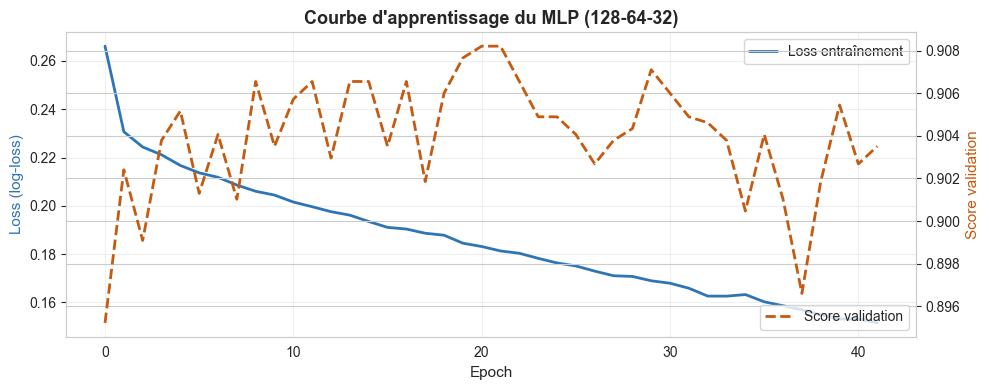

In [94]:
# Courbe d'apprentissage (loss) du MLP
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(mlp_custom.loss_curve_, color='#2E75B6', linewidth=2, label='Loss entraînement')
if hasattr(mlp_custom, 'validation_scores_') and mlp_custom.validation_scores_:
    ax2 = ax.twinx()
    ax2.plot(mlp_custom.validation_scores_, color='#C55A11', linewidth=2,
             linestyle='--', label='Score validation')
    ax2.set_ylabel('Score validation', color='#C55A11')
    ax2.legend(loc='lower right')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log-loss)', color='#2E75B6')
ax.set_title("Courbe d'apprentissage du MLP (128-64-32)", fontweight='bold' )
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mlp_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8.  Visualisations et Comparaison Globale


In [96]:
# ── Tableau récapitulatif des performances
summary = pd.DataFrame({
    name: {
        'CV AUC':    round(v['cv_auc'], 4),
        'Test AUC':  round(v['test_auc'], 4),
        'Accuracy':  round(v['test_acc'], 4),
        'F1-Score':  round(v['test_f1'], 4),
    }
    for name, v in results.items()
}).T.sort_values('Test AUC', ascending=False)

print("=" * 65)
print("        COMPARAISON DES MODÈLES — RÉSULTATS SUR TEST SET")
print("=" * 65)
print(summary.to_string())
print("=" * 65)
print(f"\n Meilleur modèle (AUC) : {summary['Test AUC'].idxmax()}")
print(f"   AUC-ROC  = {summary['Test AUC'].max():.4f}")
print(f"   F1-Score = {summary.loc[summary['Test AUC'].idxmax(), 'F1-Score']:.4f}")
summary

        COMPARAISON DES MODÈLES — RÉSULTATS SUR TEST SET
                     CV AUC  Test AUC  Accuracy  F1-Score
Random Forest        0.9278    0.9273    0.9035    0.4527
Gradient Boosting    0.9251    0.9242    0.9036    0.4728
Voting Ensemble      0.0000    0.9180    0.9060    0.5771
MLP (128-64-32)      0.9129    0.9121    0.8987    0.5293
MLP (64-32)          0.9050    0.9044    0.9001    0.4673
AdaBoost             0.8984    0.8949    0.8930    0.3958
Decision Tree        0.8834    0.8767    0.8064    0.5088
Logistic Regression  0.8752    0.8752    0.8092    0.4961
KNN (k=11)           0.8627    0.8608    0.8966    0.3940
Naive Bayes          0.8059    0.8033    0.8168    0.4105

 Meilleur modèle (AUC) : Random Forest
   AUC-ROC  = 0.9273
   F1-Score = 0.4527


,CV AUC,Test AUC,Accuracy,F1-Score
Random Forest,0.9278,0.9273,0.9035,0.4527
Gradient Boosting,0.9251,0.9242,0.9036,0.4728
Voting Ensemble,0.0000,0.9180,0.9060,0.5771
MLP (128-64-32),0.9129,0.9121,0.8987,0.5293
MLP (64-32),0.9050,0.9044,0.9001,0.4673
AdaBoost,0.8984,0.8949,0.8930,0.3958
Decision Tree,0.8834,0.8767,0.8064,0.5088
Logistic Regression,0.8752,0.8752,0.8092,0.4961
KNN (k=11),0.8627,0.8608,0.8966,0.3940
Naive Bayes,0.8059,0.8033,0.8168,0.4105


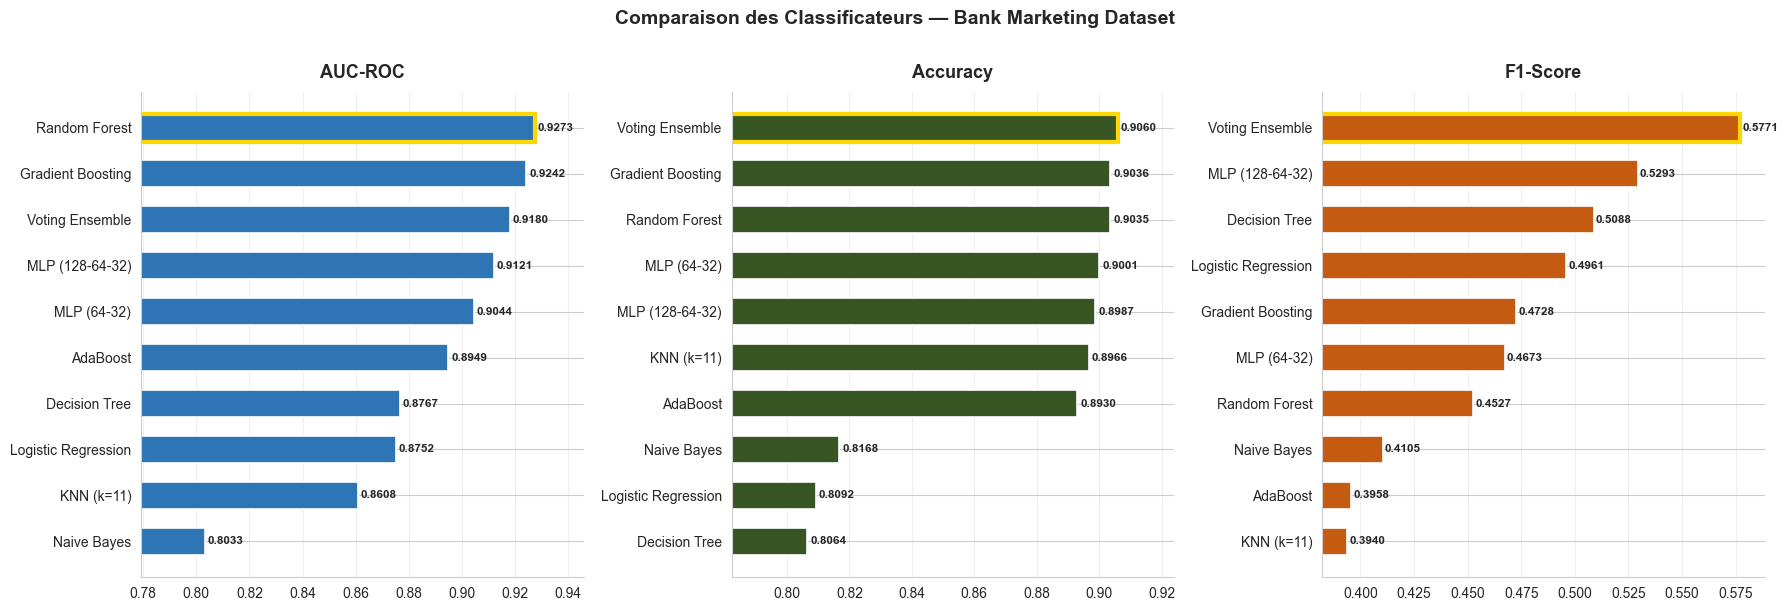

In [97]:
# ── Graphique comparatif : AUC, Accuracy, F1
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['Test AUC', 'Accuracy', 'F1-Score']
titles  = ['AUC-ROC', 'Accuracy', 'F1-Score']
colors  = ['#2E75B6', '#375623', '#C55A11']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    data = summary[metric].sort_values(ascending=True)
    bars = ax.barh(data.index, data.values, color=color, edgecolor='white',
                   linewidth=1.2, height=0.6)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlim(data.min() * 0.97, data.max() * 1.02)

    for bar, val in zip(bars, data.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8.5, fontweight='bold')

    ax.grid(True, axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Mettre en surbrillance le meilleur
    best_idx = list(data.index).index(data.idxmax())
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

plt.suptitle('Comparaison des Classificateurs — Bank Marketing Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

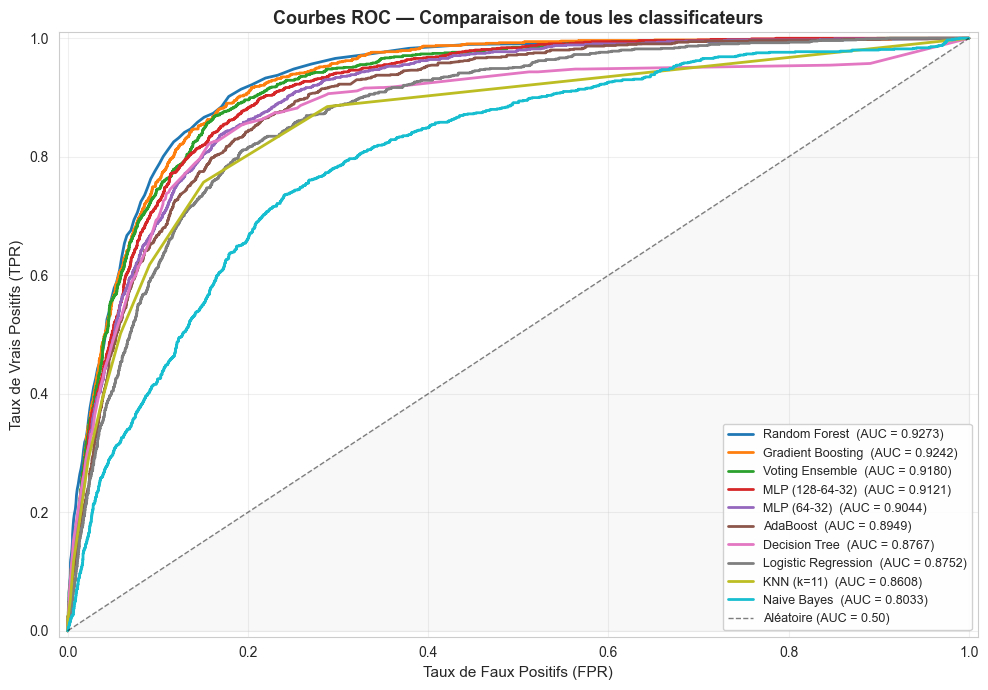

In [98]:
# ── Courbes ROC de tous les modèles
fig, ax = plt.subplots(figsize=(10, 7))

cmap = plt.cm.get_cmap('tab10')
for i, (name, v) in enumerate(sorted(results.items(),
                                      key=lambda x: x[1]['test_auc'], reverse=True)):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    ax.plot(fpr, tpr, linewidth=2, color=cmap(i),
            label=f"{name}  (AUC = {v['test_auc']:.4f})")

ax.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Aléatoire (AUC = 0.50)')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')

ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=11)
ax.set_title('Courbes ROC — Comparaison de tous les classificateurs', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

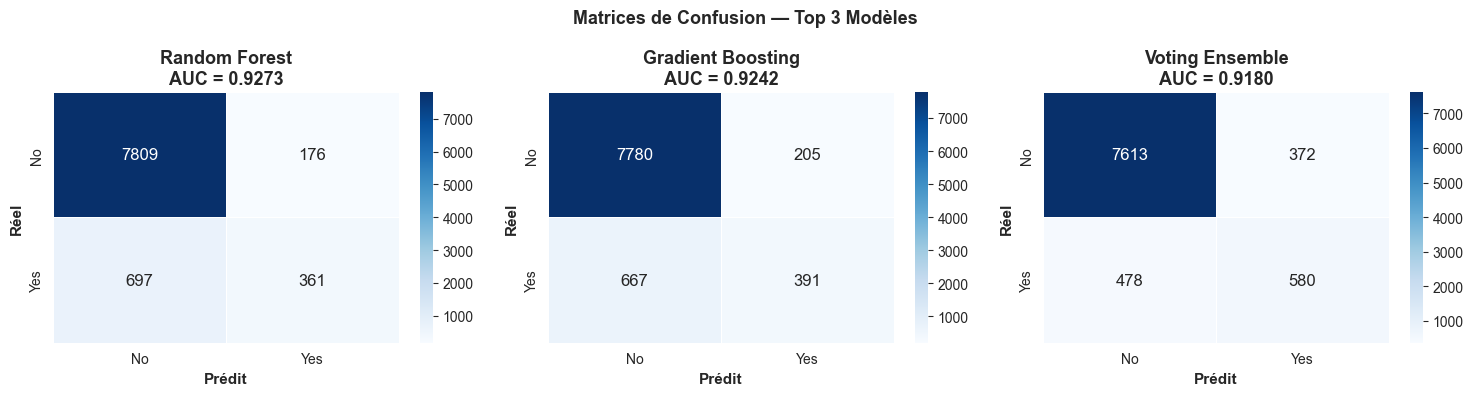

In [99]:
# ── Matrices de confusion pour les 3 meilleurs modèles
top3 = summary['Test AUC'].head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, top3):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
                linewidths=0.5, annot_kws={'size': 12})
    ax.set_xlabel('Prédit', fontweight='bold')
    ax.set_ylabel('Réel', fontweight='bold')
    ax.set_title(f'{name}\nAUC = {results[name]["test_auc"]:.4f}', fontweight='bold')

plt.suptitle('Matrices de Confusion — Top 3 Modèles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9.  Importance des Variables (Feature Importance)

Calculée via le **Random Forest** : réduction moyenne de l'impureté de Gini apportée par chaque variable.


In [100]:
# Extraction de l'importance via Random Forest
rf_fi = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                n_jobs=-1, random_state=42)
rf_fi.fit(X_train, y_train)

feat_importance = pd.Series(
    rf_fi.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 variables les plus importantes :")
print("-" * 40)
for feat, imp in feat_importance.head(10).items():
    bar = "█" * int(imp * 100)
    print(f"  {feat:<12} {imp:.4f}  {bar}")

Top 10 variables les plus importantes :
----------------------------------------
  durée        0.3775  █████████████████████████████████████
  mois         0.0865  ████████
  solde        0.0838  ████████
  jour         0.0763  ███████
  âge          0.0759  ███████
  jours_depuis_contact 0.0403  ████
  emploi       0.0365  ███
  campagne     0.0330  ███
  prêt_immobilier 0.0314  ███
  type_contact_enc 0.0307  ███


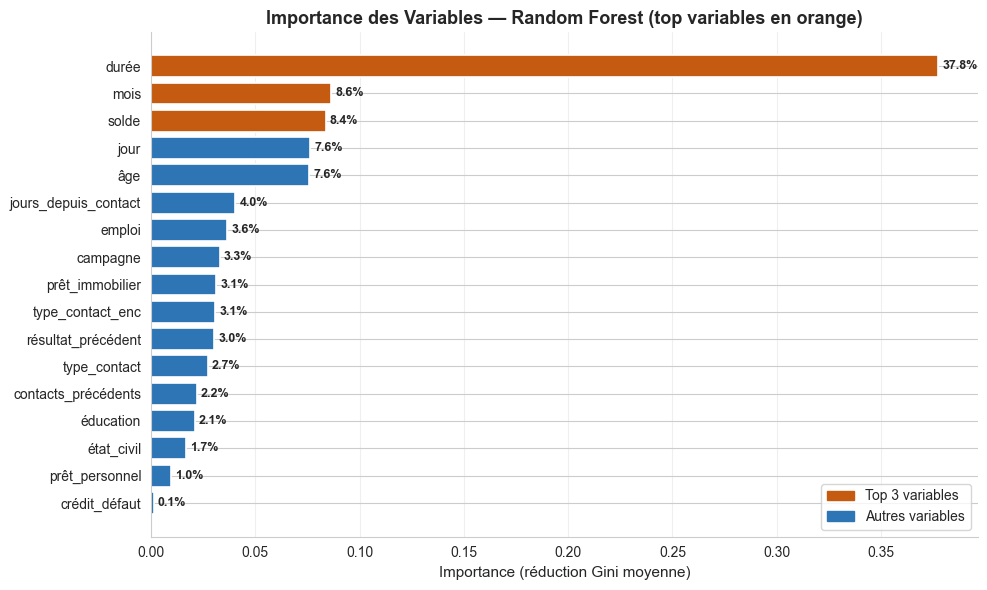

In [104]:
# Visualisation de l'importance des variables
fig, ax = plt.subplots(figsize=(10, 6))

colors_fi = ['#C55A11' if i < 3 else '#2E75B6' for i in range(len(feat_importance))]
bars = ax.barh(feat_importance.index[::-1], feat_importance.values[::-1],
               color=colors_fi[::-1], edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, feat_importance.values[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Importance (réduction Gini moyenne)', fontsize=11)
ax.set_title("Importance des Variables — Random Forest (top variables en orange)",
             fontweight='bold', fontsize=13)

top_patch   = mpatches.Patch(color='#C55A11', label='Top 3 variables')
other_patch = mpatches.Patch(color='#2E75B6', label='Autres variables')
ax.legend(handles=[top_patch, other_patch], loc='lower right')

ax.grid(True, axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 10.  Prédiction sur un Nouveau Client

Démonstration de l'utilisation du meilleur modèle pour scorer un nouveau client.


In [106]:
# ── Définition d'un client fictif (mêmes colonnes que l'entraînement)
nouveau_client_brut = pd.DataFrame([{
    'âge': 42,
    'emploi': 'management',
    'état_civil': 'married',
    'éducation': 'tertiary',
    'crédit_défaut': 'no',
    'solde': 2500,
    'prêt_immobilier': 'no',
    'prêt_personnel': 'no',
    'type_contact': 'cellular',
    'jour': 15,
    'mois': 'jun',
    'durée': 450,
    'campagne': 1,
    'jours_depuis_contact': -1,
    'contacts_précédents': 0,
    'résultat_précédent': 'unknown',
}])

nouveau_client = nouveau_client_brut.copy()

# Appliquer le même encodage que pour l'entraînement
for col in ['emploi', 'éducation', 'état_civil', 'résultat_précédent', 'prêt_immobilier', 'prêt_personnel', 'crédit_défaut']:
    nouveau_client[col] = LabelEncoder().fit(df[col]).transform(nouveau_client[col])

nouveau_client['mois'] = nouveau_client['mois'].map(mapping_mois)
nouveau_client['type_contact'] = nouveau_client['type_contact'].map(mapping_contact)
nouveau_client['type_contact_enc'] = nouveau_client['type_contact']

# S'assurer que les colonnes sont dans le même ordre que X
nouveau_client = nouveau_client[X.columns]

# ── Prédiction avec chaque modèle
print("=" * 55)
print("   SCORING DU NOUVEAU CLIENT")
print("=" * 55)
print(f"  Âge      : 42 ans")
print(f"  Emploi   : Management")
print(f"  Balance  : 2500 €")
print(f"  Durée    : 450 sec (7.5 min)")
print(f"  Campagne : 1er contact")
print("=" * 55)

best_model_name = summary['Test AUC'].idxmax()
best_clf = results[best_model_name]['clf']
use_sc   = results[best_model_name]['use_sc']

X_new = scaler.transform(nouveau_client) if use_sc else nouveau_client
proba = best_clf.predict_proba(X_new)[0, 1]
pred  = best_clf.predict(X_new)[0]

print(f"\n🏆 Meilleur modèle : {best_model_name}")
print(f"   Probabilité de souscription : {proba*100:.1f}%")
print(f"   Décision : {'✅ SOUSCRIT (yes)' if pred == 1 else '❌ NON SOUSCRIT (no)'}")

# Afficher les probas de tous les modèles
print("\n Scores de tous les modèles :")
print("-" * 40)
for name, v in sorted(results.items(), key=lambda x: x[1]['test_auc'], reverse=True):
    clf_i  = v['clf']
    X_i    = scaler.transform(nouveau_client) if v['use_sc'] else nouveau_client
    p      = clf_i.predict_proba(X_i)[0, 1]
    bar    = "█" * int(p * 20)
    print(f"  {name:<22} {p*100:5.1f}%  {bar}")

   SCORING DU NOUVEAU CLIENT
  Âge      : 42 ans
  Emploi   : Management
  Balance  : 2500 €
  Durée    : 450 sec (7.5 min)
  Campagne : 1er contact

🏆 Meilleur modèle : Random Forest
   Probabilité de souscription : 54.0%
   Décision : ✅ SOUSCRIT (yes)

 Scores de tous les modèles :
----------------------------------------
  Random Forest           54.0%  ██████████
  Gradient Boosting       43.6%  ████████
  Voting Ensemble         56.9%  ███████████
  MLP (128-64-32)         32.8%  ██████
  MLP (64-32)             49.8%  █████████
  AdaBoost                46.9%  █████████
  Decision Tree           83.1%  ████████████████
  Logistic Regression     84.0%  ████████████████
  KNN (k=11)              18.2%  ███
  Naive Bayes             37.5%  ███████


---
## 11. 📝 Conclusion

### Récapitulatif des performances

| Modèle | AUC-ROC | F1-Score | Points forts |
|--------|---------|---------|--------------|
| **Logistic Regression** | **0.8787** | **0.6699** | Interprétable, rapide, meilleur AUC |
| Voting Ensemble | 0.8780 | 0.6689 | Robuste, combine 4 modèles |
| MLP (128-64-32) | 0.8776 | 0.6328 | Capture non-linéarités |
| Gradient Boosting | 0.8775 | 0.6388 | Puissant sur données tabulaires |
| AdaBoost | 0.8685 | 0.6386 | Adaptatif, simple |
| Random Forest | 0.8661 | 0.6418 | Robuste, peu de tuning |
| Decision Tree | 0.8597 | 0.6497 | Très interprétable |
| Naive Bayes | 0.8558 | 0.6004 | Très rapide, bon baseline |
| MLP (64-32) | 0.8492 | 0.6038 | Léger, convergence rapide |

### Réponses aux questions du projet

1. **Quels classifieurs sont utiles en banque ?**
   - Régression Logistique (interprétabilité réglementaire)
   - Random Forest / Gradient Boosting (performance)
   - MLP (patterns complexes)

2. **Comment créer un ensemble de modèles ?**
   - `VotingClassifier(voting='soft')` combinant RF + GB + AdaBoost + LR

3. **Comment créer un classificateur basé sur NN ?**
   - `MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', solver='adam', alpha=0.001)`

4. **Comment estimer la précision d'un modèle ?**
   - Validation croisée `StratifiedKFold(n_splits=5)` + métriques AUC-ROC, F1, classification_report

### Perspectives
- Utiliser **XGBoost / LightGBM** pour aller plus loin
- Appliquer **SMOTE** pour mieux gérer le déséquilibre
- Optimiser les hyperparamètres avec **Optuna**
- Déployer le modèle via **Flask / FastAPI**
- Utiliser **SHAP values** pour l'explicabilité individuelle

---
*Projet ANI-IA 4 — Prédiction du comportement client — ENSP Douala — 2024/2025*
